In [9]:
import pandas as pd
from matplotlib import pyplot as plt
from prophet import Prophet
from datetime import datetime
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import numpy as np

In [10]:
df = pd.read_csv('./data/fct_campaign.csv')
df

,date,platform,campaign_type,campaign_id,channel,target_segment,objective,expected_uplift,country,impressions,clicks,CTR,ad_spend,conversions,ROAS,revenue,conversion_lift,click_to_conversion_rate
0,2021-01-20,NaN,NaN,12.0,Email,Churn Risk,Acquisition,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-31,NaN,NaN,44.0,Affiliate,All,Reactivation,0.141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-02-14,NaN,NaN,50.0,Email,Churn Risk,Retention,0.023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-03-19,NaN,NaN,25.0,Paid Search,High Value,Cross-sell,0.119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-04-09,NaN,NaN,49.0,Paid Search,Deal Seekers,Reactivation,0.128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1845,2024-12-30,Meta Ads,Display,NaN,NaN,NaN,NaN,NaN,USA,108152.0,4250.0,0.0393,3060.00,160.0,4.07,12452.25,NaN,0.037647
1846,2024-12-30,Meta Ads,Search,NaN,NaN,NaN,NaN,NaN,UAE,18487.0,693.0,0.0375,339.57,36.0,22.87,7765.15,NaN,0.051948
1847,2024-12-30,TikTok Ads,Video,NaN,NaN,NaN,NaN,NaN,India,194407.0,13122.0,0.0675,11153.70,379.0,5.05,56289.95,NaN,0.028883
1848,2024-12-30,TikTok Ads,Search,NaN,NaN,NaN,NaN,NaN,Germany,196349.0,8325.0,0.0424,5744.25,398.0,7.39,42464.91,NaN,0.047808


In [18]:
df_clean = df[["date", "country", "impressions", "clicks", "CTR", "ad_spend", "conversions", "revenue"]]
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.rename(columns={"date": "ds"})
df_clean = df_clean.dropna(subset=['revenue'])
# df.head(10)
df_clean['country'].unique()

<StringArray>
['USA', 'India', 'UK', 'Germany', 'Canada', 'UAE', 'Australia']
Length: 7, dtype: str

In [21]:
# North America Data
df_na = df_clean[(df_clean['country']=='USA')]
# print(df_na)


# Sum the revenue
# df_daily = df.groupby('ds')['Revenue'].sum().reset_index()
# for re in regressors:
df_daily = df_clean.groupby('ds').agg({
        'impressions': 'sum',
        'clicks': 'sum',
        'CTR': 'sum',
        'ad_spend': 'sum',
        'conversions': 'sum',
        'revenue': 'sum'
    }).reset_index()


df_daily = df_daily.sort_values('ds')
df_daily = df_daily.rename(columns={'revenue': 'y'})
# df_daily['y'] = np.log1p(df_daily['y'])
# print(df_daily)
# print(df_daily.columns)

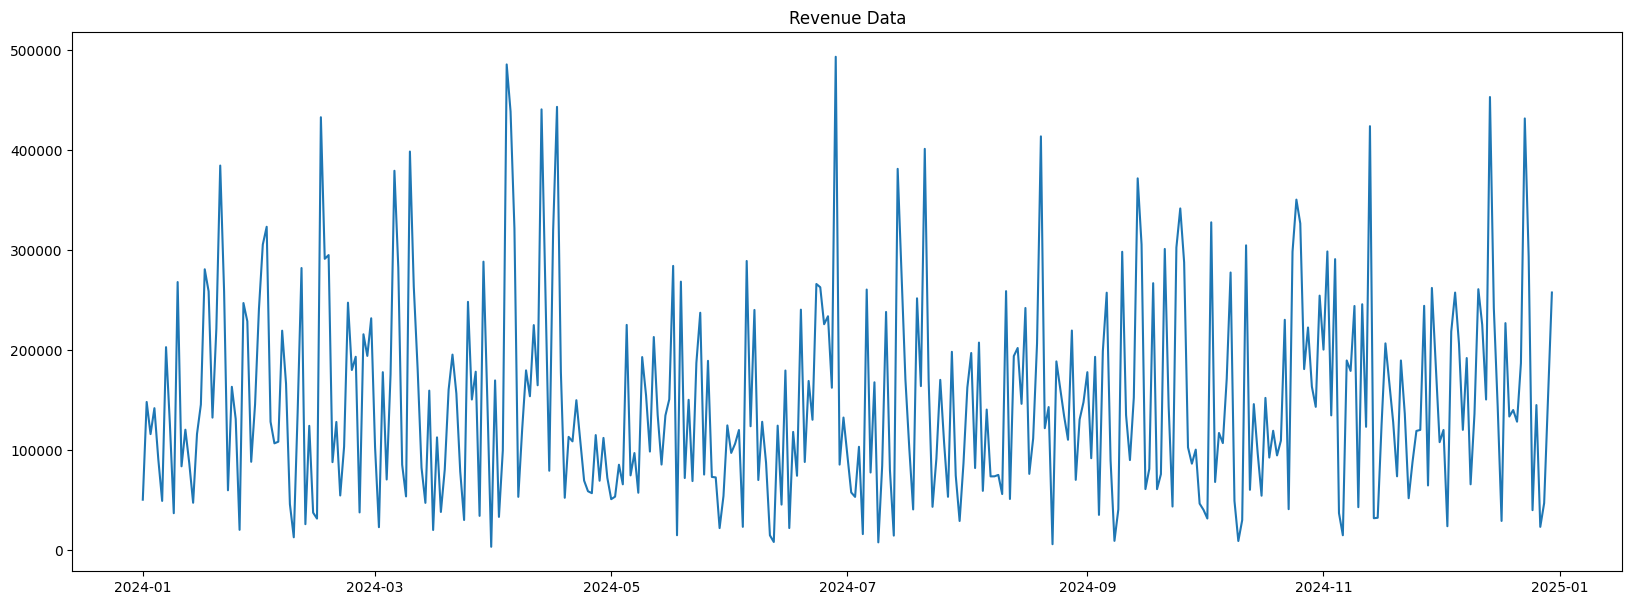

In [22]:
plt.subplots(figsize=(20,7))
plt.plot(df_daily['ds'],df_daily['y'])
plt.title('Revenue Data')
plt.show()

In [23]:
# Including Black Friday
black_friday = pd.DataFrame({
  'holiday': 'black_friday',
  'ds': pd.to_datetime(['2024-11-29']),
  'lower_window': 0,
  'upper_window': 3, 
})

16:40:19 - cmdstanpy - INFO - Chain [1] start processing
16:40:19 - cmdstanpy - INFO - Chain [1] done processing


            ds           yhat    yhat_lower     yhat_upper
385 2025-01-25  156075.836802    674.031373  318878.506701
386 2025-01-26  175327.766748  10590.958815  334108.530341
387 2025-01-27  136925.991389 -33035.837114  292695.754080
388 2025-01-28  140061.585770 -26201.415988  295209.118236
389 2025-01-29  155628.128486  -1370.614504  318709.591827


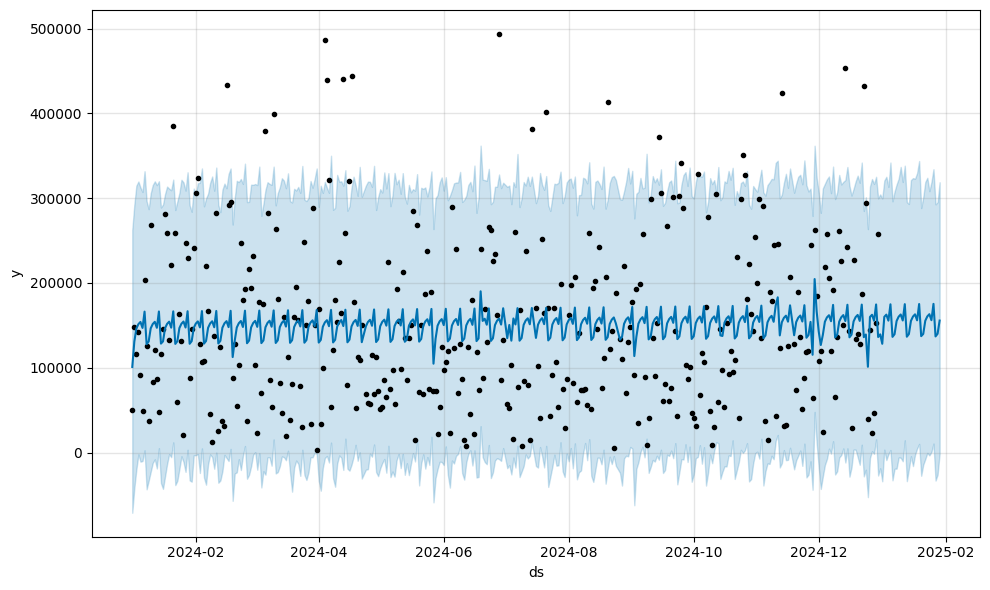

  0%|          | 0/3 [00:00<?, ?it/s]16:40:20 - cmdstanpy - INFO - Chain [1] start processing
16:40:20 - cmdstanpy - INFO - Chain [1] done processing
16:40:20 - cmdstanpy - INFO - Chain [1] start processing
16:40:20 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 2/3 [00:00<00:00, 15.56it/s]16:40:20 - cmdstanpy - INFO - Chain [1] start processing
16:40:20 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 3/3 [00:00<00:00, 14.87it/s]


   horizon           mse           rmse            mae      mape     mdape  \
0   3 days  1.171742e+10  108247.020310   90766.715227  1.289804  0.536022   
1   4 days  1.234971e+10  111129.261210   91678.035850  1.004695  0.436469   
2   5 days  9.767982e+09   98833.103071   87647.501557  1.120439  0.515884   
3   6 days  9.119287e+09   95494.958392   86382.176452  1.681333  0.515884   
4   7 days  7.955177e+09   89191.800296   79255.011435  1.554751  0.459250   
5   8 days  6.262014e+09   79132.890504   64922.748925  1.155075  0.221584   
6   9 days  7.385373e+09   85938.193198   72807.270690  2.384564  0.481924   
7  10 days  8.988634e+09   94808.406267   81238.056806  3.124124  1.428804   
8  11 days  1.442580e+10  120107.443846  109693.363401  2.455271  0.554664   
9  12 days  1.283771e+10  113303.610140   99986.014412  1.099117  0.554664   
10 13 days  1.799979e+10  134163.286099  102450.400428  0.549316  0.439555   
11 14 days  2.581939e+10  160684.124042  115916.591171  0.913190

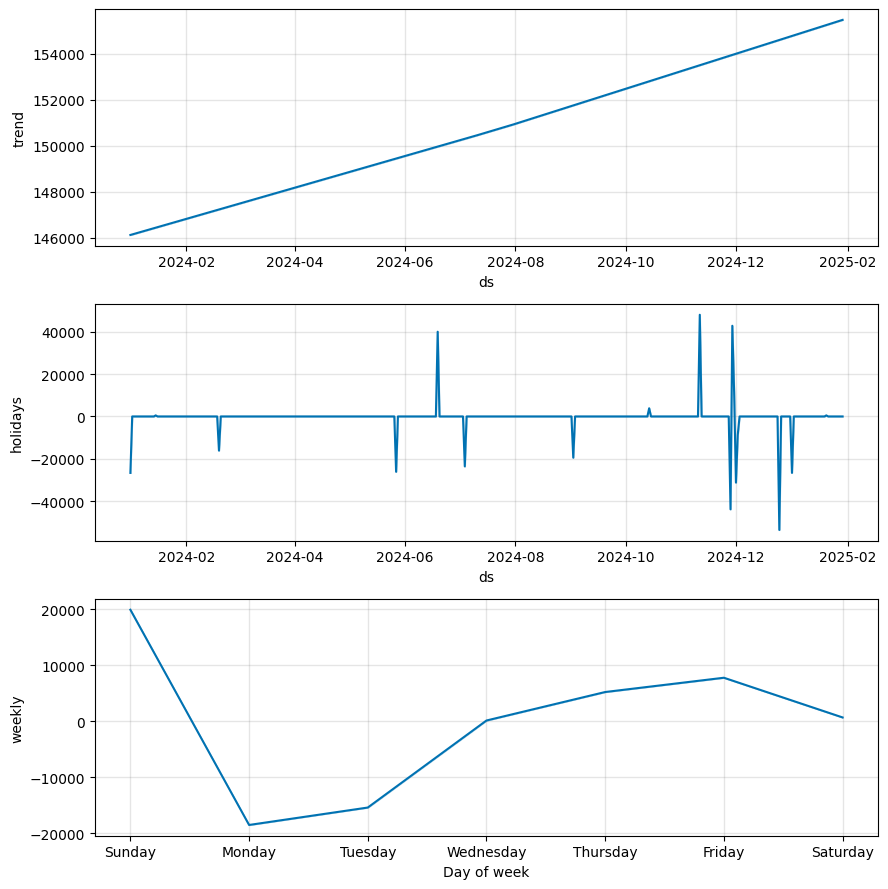

Accuracy (30 days): 71.41%


In [24]:
# Model 1 (Without Regressors)

m = Prophet(interval_width = 0.90, 
            holidays=black_friday)
# m = Prophet(interval_width = 0.90)


# m.add_seasonality(name='weekly', period=7, fourier_order=10, prior_scale=0.1)
m.add_country_holidays(country_name='US')

m.fit(df_daily)

future = m.make_future_dataframe(periods=30)


forecast = m.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
# print(forecast.tail())

fig = m.plot(forecast)
plt.show()

df_cv = cross_validation(
    m, 
    initial='270 days',   
    period='30 days',    
    horizon='30 days'    
)

# Calculate performance metrics
df_p = performance_metrics(df_cv)
print(df_p)

fig2 = m.plot_components(forecast)
plt.show()

# Calculate Accuracy
df_p['accuracy_smape'] = (1 - (df_p['smape'] / 2)) * 100

overall_accuracy = df_p['accuracy_smape'].mean()

print(f"Accuracy (30 days): {overall_accuracy:.2f}%")


In [ ]:
print(df_cv)
m.plot(df_cv)

16:41:22 - cmdstanpy - INFO - Chain [1] start processing
16:41:22 - cmdstanpy - INFO - Chain [1] done processing


            ds           yhat    yhat_lower     yhat_upper
385 2025-01-25  149922.768977  82644.119395  213253.308889
386 2025-01-26  146934.970070  82312.008296  209372.195161
387 2025-01-27  142282.642769  76102.919077  204951.477560
388 2025-01-28  143717.762316  80596.549048  208558.712513
389 2025-01-29  150114.339618  84549.289282  216710.729937


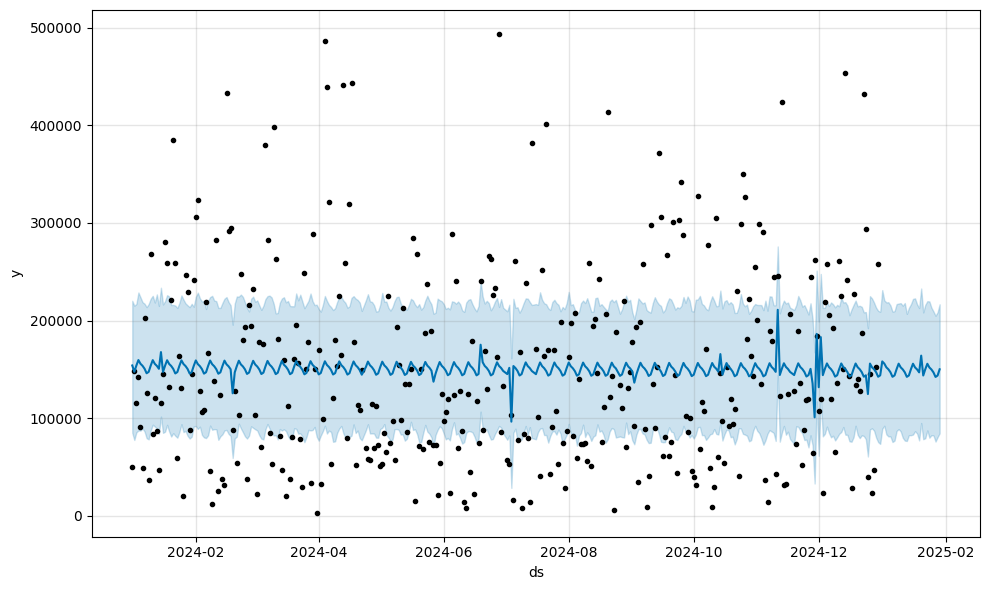

  0%|          | 0/3 [00:00<?, ?it/s]16:41:22 - cmdstanpy - INFO - Chain [1] start processing
16:41:22 - cmdstanpy - INFO - Chain [1] done processing
16:41:22 - cmdstanpy - INFO - Chain [1] start processing
16:41:22 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 2/3 [00:00<00:00, 12.23it/s]16:41:22 - cmdstanpy - INFO - Chain [1] start processing
16:41:22 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 3/3 [00:00<00:00, 12.30it/s]


   horizon           mse          rmse           mae      mape     mdape  \
0   3 days  3.050571e+09  55231.972950  43466.440354  0.442144  0.216207   
1   4 days  2.616678e+09  51153.476601  38611.667776  0.390367  0.200153   
2   5 days  1.398727e+09  37399.552310  27562.779582  0.330002  0.187573   
3   6 days  1.897679e+09  43562.357309  35289.310828  0.498440  0.246118   
4   7 days  1.929720e+09  43928.580552  34821.910168  0.478030  0.246118   
5   8 days  1.301922e+09  36082.157771  25520.661099  0.316991  0.117981   
6   9 days  2.967550e+08  17226.579483  14645.711700  0.406510  0.117981   
7  10 days  4.773417e+08  21848.151304  19442.087359  0.570283  0.248799   
8  11 days  1.970943e+09  44395.302443  36206.225808  0.510040  0.300005   
9  12 days  2.317884e+09  48144.406221  42122.575734  0.319674  0.296694   
10 13 days  4.384072e+09  66212.325160  54547.165494  0.315261  0.250484   
11 14 days  3.204295e+09  56606.492200  39050.819565  0.285506  0.232142   
12 15 days  

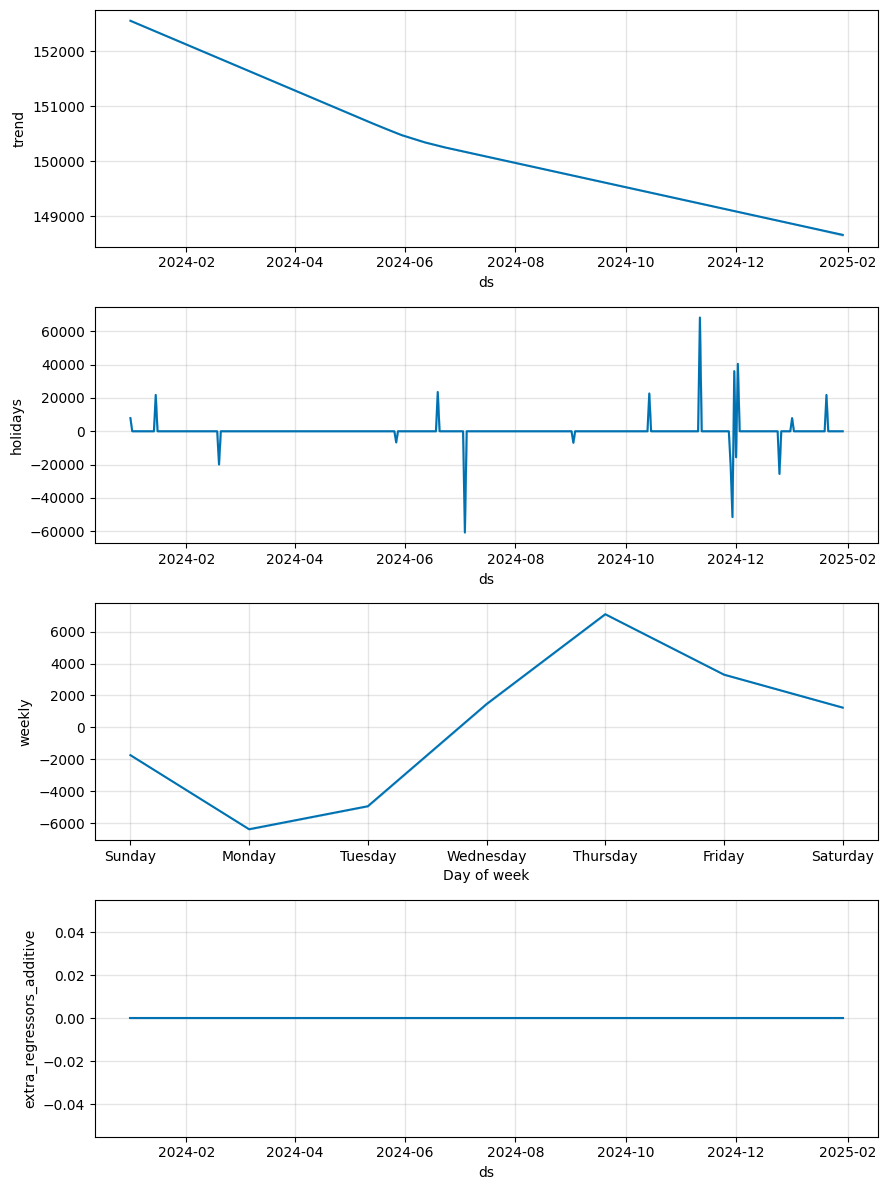

Accuracy (30 days): 85.97%


In [25]:
# Model 2 (With Regressors)

m = Prophet(interval_width = 0.90, 
            holidays=black_friday)

# m.add_seasonality(name='weekly', period=7, fourier_order=10, prior_scale=0.1)
m.add_country_holidays(country_name='US')

regressors = ["impressions", "clicks", "CTR", "ad_spend", "conversions"]

for regressor in regressors:
    m.add_regressor(regressor)

m.fit(df_daily)

future = m.make_future_dataframe(periods=30)

for futures in regressors:
    future[futures] = df_daily[futures].mean()

forecast = m.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
# print(forecast.tail())

fig = m.plot(forecast)
plt.show()

df_cv = cross_validation(
    m, 
    initial='270 days',   
    period='30 days',    
    horizon='30 days'    
)

# Calculate performance metrics
df_p = performance_metrics(df_cv)
print(df_p)

fig2 = m.plot_components(forecast)
plt.show()


# Calculate Accuracy
df_p['accuracy_smape'] = (1 - (df_p['smape'] / 2)) * 100

overall_accuracy = df_p['accuracy_smape'].mean()

print(f"Accuracy (30 days): {overall_accuracy:.2f}%")


16:47:55 - cmdstanpy - INFO - Chain [1] start processing
16:47:55 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/2 [00:00<?, ?it/s]16:47:55 - cmdstanpy - INFO - Chain [1] start processing
16:47:55 - cmdstanpy - INFO - Chain [1] done processing
16:47:55 - cmdstanpy - INFO - Chain [1] start processing
16:47:55 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 2/2 [00:00<00:00, 13.43it/s]


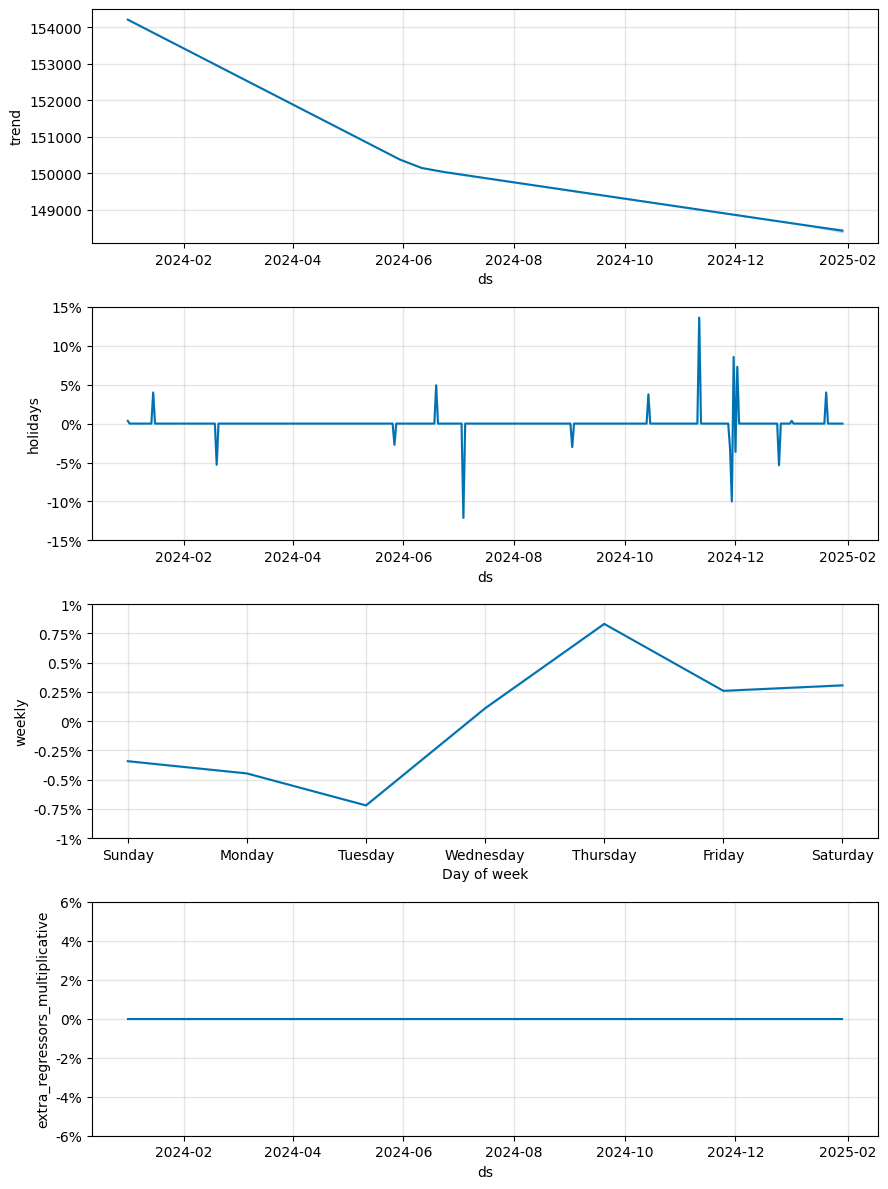

Accuracy (30 days): 87.24%


In [47]:
# Model 2 (With Regressors)

m = Prophet(interval_width = 0.90, 
            holidays=black_friday,
           seasonality_mode='multiplicative')

m.add_seasonality(name='weekly', period=7, fourier_order=4, prior_scale=0.01)
m.add_country_holidays(country_name='US')

regressors = ["impressions", "clicks", "CTR", "ad_spend", "conversions"]

for regressor in regressors:
    m.add_regressor(regressor)

m.fit(df_daily)

future = m.make_future_dataframe(periods=30)

for futures in regressors:
    future[futures] = df_daily[futures].mean()

forecast = m.predict(future)
# print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
# print(forecast.tail())

# fig = m.plot(forecast)
# plt.show()

df_cv = cross_validation(
    m, 
    initial='270 days',   
    period='60 days',    
    horizon='30 days'    
)

# Calculate performance metrics
df_p = performance_metrics(df_cv)
# print(df_p)

fig2 = m.plot_components(forecast)
plt.show()


# Calculate Accuracy
df_p['accuracy_smape'] = (1 - (df_p['smape'] / 2)) * 100

overall_accuracy = df_p['accuracy_smape'].mean()

print(f"Accuracy (30 days): {overall_accuracy:.2f}%")


In [52]:
# Model 3 (Hyperparameter Test)
# REFERENCE: https://velog.io/@sooyeon/prophet-crossvalidation

hyperparameters = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0]
}

all_hyperparam = [dict(zip(hyperparameters.keys(), v)) for v in itertools.product(*hyperparameters.values())]
smape = []


for hyper in all_hyperparam:
    m = Prophet(**hyper,
                interval_width = 0.90, 
                holidays=black_friday,
               seasonality_mode='multiplicative')
    
    m.add_seasonality(name='weekly', period=7, fourier_order=4, prior_scale=0.01)
    m.add_country_holidays(country_name='US')
    
    regressors = ["impressions", "clicks", "CTR", "ad_spend", "conversions"]
    
    for regressor in regressors:
        m.add_regressor(regressor)
    
    m.fit(df_daily)
    
    future = m.make_future_dataframe(periods=30)
    
    for futures in regressors:
        future[futures] = df_daily[futures].mean()
    
    forecast = m.predict(future)
    # print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())
    # print(forecast.tail())
    
    # fig = m.plot(forecast)
    # plt.show()
    
    df_cv = cross_validation(
        m, 
        initial='270 days',   
        period='60 days',    
        horizon='30 days'    
    )
    
    # Calculate performance metrics
    df_p = performance_metrics(df_cv)
    # print(df_p)
    
    # fig2 = m.plot_components(forecast)
    # plt.show()
    
    
    # Calculate Accuracy
    df_p['accuracy_smape'] = (1 - (df_p['smape'] / 2)) * 100
    
    overall_accuracy = df_p['accuracy_smape'].mean()
    smape.append(overall_accuracy)
    # print(f"Accuracy (30 days): {overall_accuracy:.2f}%")


results = pd.DataFrame(all_hyperparam)
results['accuracy'] = smape
print(results)


17:00:40 - cmdstanpy - INFO - Chain [1] start processing
17:00:40 - cmdstanpy - INFO - Chain [1] done processing
17:00:40 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
17:00:40 - cmdstanpy - INFO - Chain [1] start processing
17:00:41 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/2 [00:00<?, ?it/s]17:00:41 - cmdstanpy - INFO - Chain [1] start processing
17:00:41 - cmdstanpy - INFO - Chain [1] done processing
17:00:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
17:00:41 - cmdstanpy - INFO - Chain [1] start processing
17:00:41 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 1/2 [00:00<00:00,  2.49it/s]17:00:41 - cmdstanpy - INFO - Chain [1] start processing
17:00:41 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 2/2 [00:00<00:00,  4.14it/s]
17:00:41 - cmdstanpy - IN

    changepoint_prior_scale  seasonality_prior_scale  holidays_prior_scale  \
0                     0.001                     0.01                  0.01   
1                     0.001                     0.01                  0.10   
2                     0.001                     0.01                  1.00   
3                     0.001                     0.10                  0.01   
4                     0.001                     0.10                  0.10   
5                     0.001                     0.10                  1.00   
6                     0.001                     1.00                  0.01   
7                     0.001                     1.00                  0.10   
8                     0.001                     1.00                  1.00   
9                     0.001                    10.00                  0.01   
10                    0.001                    10.00                  0.10   
11                    0.001                    10.00            